# A Hybrid CNN + One-Class SVM Anomaly Detector on Top of MEWMA — A Beginner's Guide

This notebook builds a **hybrid monitoring scheme**: instead of watching the classical MEWMA $T^2$ statistic alone, we feed a short rolling window of the process into a small **1D convolutional autoencoder**, turn its bottleneck features plus its reconstruction error into a **One-Class SVM** anomaly score, and fuse that score with the classical $T^2$ into one combined chart. We then honestly ask, via Monte Carlo ARL, whether any of this actually helps.

This notebook explicitly builds on three earlier notebooks in this repository and will only *briefly recap* each rather than re-deriving them:

* **`MEWMA_Control_Chart_Tutorial.ipynb`** — the classical MEWMA $T^2$ chart, control limits, and Monte Carlo ARL estimation. We reuse its notation and helper-function style throughout.
* **`SVM_and_OneClassSVM_Tutorial.ipynb`** — margin geometry, the kernel trick, and One-Class SVM's $\nu$/$\gamma$ parameters. We assume this is already familiar.
* **`Dog_Breed_CNN_Tutorial.ipynb`** — convolution, padding/stride, ReLU, backprop, and Adam, all from scratch, plus this repository's PyTorch conventions. We reuse its training-loop style and only explain what's genuinely new here: 1D convolution over *time* windows, autoencoders, and reconstruction error as a label-free anomaly signal.

## Roadmap

1. Recap the classical MEWMA / $T^2$ chart (Case K, $\Sigma=\mathbf{I}$ special case) and introduce a vectorized multi-path simulator we'll need for everything that follows.
2. Honestly motivate what a CNN + One-Class SVM could add on top of $T^2$ — and what it probably can't.
3. Turn simulated paths into rolling $(Z_1, Z_2, T^2)$ windows.
4. Build a small 1D convolutional autoencoder, with the exact arithmetic showing it preserves the window length end to end.
5. Train it on in-control windows only (no labels, ever).
6. Turn its output into a 17-dimensional feature vector: 16 bottleneck features plus 1 reconstruction-error scalar.
7. Fit a One-Class SVM on those features, and turn its decision function into a $[0,1]$ anomaly score.
8. Fuse the anomaly score with $T^2$ into one hybrid score, and calibrate its control limit by Monte Carlo — exactly as we calibrated $h$ for the univariate and multivariate EWMA charts.
9. Repeat everything at a second smoothing constant $\lambda$, since $\lambda$ changes the very statistic the CNN is trained on.
10. Compare classical MEWMA against the hybrid chart, at both $\lambda$ values, via Monte Carlo ARL — and give an honest verdict.

## 1. Setup

Same core toolset as the other ML-flavored notebooks in this repo (`torch` for the autoencoder, `scikit-learn` for the One-Class SVM), plus `numpy`/`pandas`/`matplotlib`. We reuse the same random seed as every other notebook here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM

# Fixed seed -> reproducible simulations (same seed used throughout this repo)
RNG = np.random.default_rng(seed=795)
torch.manual_seed(795)
DEVICE = torch.device("cpu")

# "ML notebook" style, matching Dog_Breed_CNN_Tutorial.ipynb / SVM_and_OneClassSVM_Tutorial.ipynb
plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

# Colour palette: reuse the MEWMA notebook's control-chart colours, plus two new fixed
# colours identifying the two competing monitoring schemes (never cycled/reassigned).
COL_V1        = "#4C72B0"
COL_CL        = "#55A868"
COL_LIMITS    = "#C44E52"
COL_OOC       = "#C44E52"
COL_CLASSICAL = "#4C72B0"   # the classical MEWMA T^2 monitor
COL_HYBRID    = "#8172B2"   # the hybrid CNN+OCSVM+MEWMA monitor


## 2. Recap: the classical MEWMA / $T^2$ chart

As in `MEWMA_Control_Chart_Tutorial.ipynb`, we work in **Case K** (known in-control parameters) with $p=2$ correlated quality characteristics $\mathbf{X}_i \sim N_p(\boldsymbol{\mu}_0, \boldsymbol{\Sigma})$, the vector MEWMA recursion

$$
\mathbf{Z}_i = \lambda\, \mathbf{X}_i + (1-\lambda)\, \mathbf{Z}_{i-1}, \qquad \mathbf{Z}_0 = \boldsymbol{\mu}_0,
$$

and the Hotelling-type monitoring statistic $T_i^2 = (\mathbf{Z}_i - \boldsymbol{\mu}_0)'\, \boldsymbol{\Sigma}_{\mathbf{Z}}^{-1}\, (\mathbf{Z}_i - \boldsymbol{\mu}_0)$, standardised by the **asymptotic** covariance $\boldsymbol{\Sigma}_{\mathbf{Z}} = \frac{\lambda}{2-\lambda}\boldsymbol{\Sigma}$ throughout (the earlier notebook's Section 5.3 explains why: standardising by the exact time-varying covariance instead would make $T_i^2$ artificially huge for the first few points, purely because that covariance starts tiny — an artifact we don't want feeding a CNN that's supposed to learn genuine "normal" behaviour).

**This notebook simplifies one thing on purpose**: we use $\boldsymbol{\Sigma} = \mathbf{I}$ (independent, unit-variance components). This is the special case the general Mahalanobis formula above trivially reduces to — no re-derivation needed, just a plain sum of squares — and it keeps focus on what's genuinely new here (the CNN and OCSVM), since the correlated-$\boldsymbol{\Sigma}$ / shift-direction story was already told thoroughly in the earlier notebook.

### A vectorized *multi-path* simulator

Everything from here on (training the autoencoder, calibrating control limits, sweeping shift sizes) needs **many independent paths at once**, and — for the CNN — the *entire* path history, not just a running early-stopping check. So instead of the univariate/MEWMA notebook's step-by-step simulator that stops early once a path signals, we simulate fixed-length path *batches* up front, and compute run lengths afterward from the resulting score matrix (Section 8 introduces the shared helper that does this for both $T^2$ and the hybrid score).

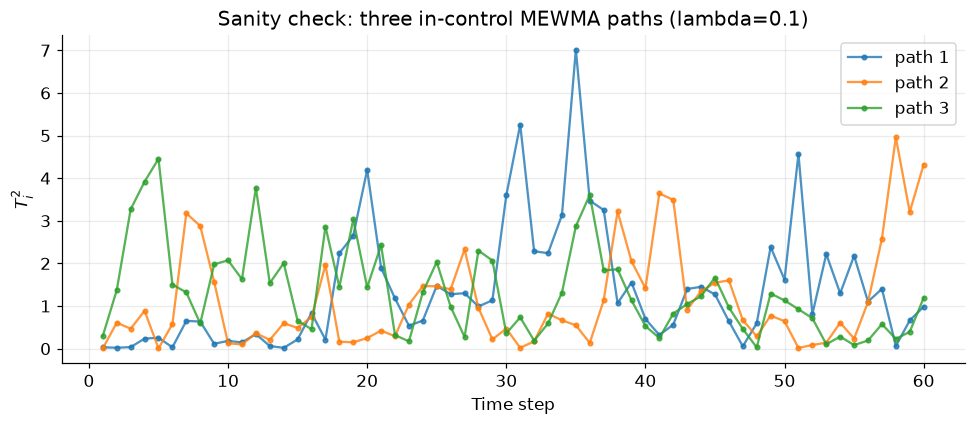

In [2]:
P_DIM = 2
MU0 = np.zeros(P_DIM)
SIGMA = np.eye(P_DIM)          # Sigma = I, per the simplification above
ARL0_TARGET = 200              # matches the sibling CNN-SVM-MEWMA project's benchmark


def simulate_mewma_paths(mu0, Sigma, lam, shift, n_paths, max_steps, rng):
    '''Simulate n_paths iid MEWMA paths of length max_steps under mean mu0+shift.
    Returns (Z, T2): Z has shape (n_paths, max_steps, p), T2 has shape (n_paths, max_steps).
    T2 is standardised by the asymptotic covariance throughout (see markdown above).'''
    p = len(mu0)
    mu0 = np.asarray(mu0, dtype=float)
    true_mean = mu0 + np.asarray(shift, dtype=float)
    factor = lam / (2 - lam)
    Sigma_inv = np.linalg.inv(Sigma)
    L = np.linalg.cholesky(Sigma)

    Z = np.empty((n_paths, max_steps, p))
    T2 = np.empty((n_paths, max_steps))
    z_prev = np.tile(mu0, (n_paths, 1))
    for t in range(max_steps):
        noise = rng.standard_normal((n_paths, p)) @ L.T
        X = true_mean + noise
        z_prev = lam * X + (1 - lam) * z_prev
        Z[:, t, :] = z_prev
        diff = z_prev - mu0
        T2[:, t] = np.einsum("ij,jk,ik->i", diff, Sigma_inv, diff) / factor
    return Z, T2


# Quick sanity check: a handful of in-control paths at lambda=0.1 should hover near T^2~1-3,
# occasionally higher, exactly like the univariate/MEWMA notebooks' in-control charts.
Z_demo, T2_demo = simulate_mewma_paths(MU0, SIGMA, lam=0.1, shift=np.zeros(P_DIM),
                                        n_paths=3, max_steps=60, rng=RNG)

fig, ax = plt.subplots(figsize=(9, 4))
for k in range(3):
    ax.plot(np.arange(1, 61), T2_demo[k], marker="o", markersize=3, alpha=0.8, label=f"path {k+1}")
ax.set_xlabel("Time step")
ax.set_ylabel("$T_i^2$")
ax.set_title("Sanity check: three in-control MEWMA paths (lambda=0.1)")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Motivation: what could a CNN + One-Class SVM add?

The classical $T^2$ statistic collapses the entire process state into one number, and it is, by construction, already close to the *right* tool for detecting exactly one kind of anomaly: a **persistent shift in the mean**. That's the anomaly we'll actually simulate below (matching the sibling research project this notebook is a smaller-scale companion to).

A CNN looking at a short rolling window of $(Z_1, Z_2, T^2)$ instead has access to the recent **shape** of the process — is it drifting smoothly, jumping around, settling into a new level — rather than just its instantaneous value. An autoencoder trained only on in-control windows learns to reconstruct "normal" shapes well; its reconstruction error, plus the compressed features it uses internally, become a self-supervised anomaly signal that needs no out-of-control labels at all — the same "no labels needed" spirit as the One-Class SVM in `SVM_and_OneClassSVM_Tutorial.ipynb`.

**An honest expectation to set before running any numbers**: since our simulated anomaly is exactly the kind of anomaly $T^2$ is already built for, a fair result here is "the hybrid chart at least keeps up with classical MEWMA," not a guaranteed win. A CNN's temporal-shape sensitivity should matter more for anomalies that *don't* look like a clean, sustained mean shift — something to keep in mind when reading the final comparison in Section 10. We'll check this story at **two** values of $\lambda$, since the smoothing constant changes both how "smooth" the underlying process looks and how much memory the CNN's window actually captures.

## 4. Rolling windows over $(Z_1, Z_2, T^2)$

For every simulated path and every time $t$, we take the last `WINDOW` values of $(Z_1, Z_2, T^2)$ — zero-padding at the start of each path so even early time points have a full window — producing one $(\text{WINDOW}, 3)$ tensor per (path, time) pair. This is exactly the windowing scheme used by the sibling research project, built here with vectorized NumPy (`np.pad` + `sliding_window_view`) rather than a Python double loop over every (path, time) pair, matching this repo's habit (see the MEWMA notebook's Section 9.1) of vectorizing anything that would otherwise loop over thousands of Monte Carlo replications.

**A rule that matters for the rest of this notebook**: every scaler and model fit from here on (the window scaler, the autoencoder, the One-Class SVM, the anomaly-score rescaler, both control limits) is fit **once**, on in-control data, and then **frozen** — reused unchanged at every later shift magnitude. If any of them were refit per shift, the whole ARL comparison would be silently cheating (recalibrating the detector to whatever data it's currently looking at, rather than testing a fixed, pre-calibrated monitor).

In [3]:
WINDOW = 12
N_CHANNELS = P_DIM + 1   # Z_1, Z_2, T^2


def make_windows(Z, T2, window):
    '''Build sliding windows of (Z_1, Z_2, T^2) over time, zero-left-padded at the start.
    Z: (n_paths, max_steps, p), T2: (n_paths, max_steps).
    Returns an array of shape (n_paths * max_steps, window, p + 1).'''
    n_paths, max_steps, p = Z.shape
    channels = np.concatenate([Z, T2[:, :, None]], axis=2)          # (n_paths, max_steps, p+1)
    padded = np.pad(channels, ((0, 0), (window - 1, 0), (0, 0)))     # zero-pad start of time axis
    windows = sliding_window_view(padded, window_shape=window, axis=1)  # (n_paths, max_steps, p+1, window)
    windows = np.moveaxis(windows, -1, 2)                            # (n_paths, max_steps, window, p+1)
    return np.ascontiguousarray(windows.reshape(n_paths * max_steps, window, p + 1))


def fit_window_scaler(windows):
    '''Channel-wise mean/std over all in-control training windows.'''
    mean = windows.mean(axis=(0, 1))
    std = windows.std(axis=(0, 1)) + 1e-8
    return mean, std


def apply_window_scaler(windows, mean, std):
    return (windows - mean) / std


# Demonstrate on the 3 in-control demo paths from Section 2
windows_demo = make_windows(Z_demo, T2_demo, WINDOW)
print("windows_demo shape:", windows_demo.shape, "-- (n_paths*max_steps, window, channels)")
print("First window (zero-padded, t=1):")
print(np.round(windows_demo[0], 2))


windows_demo shape: (180, 12, 3) -- (n_paths*max_steps, window, channels)
First window (zero-padded, t=1):
[[0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.   0.  ]
 [0.02 0.03 0.03]]


## 5. The 1D convolutional autoencoder

1D convolution over a window of time steps is the same sliding-dot-product idea from `Dog_Breed_CNN_Tutorial.ipynb`'s 2D convolution over image patches — just sliding along one time axis instead of two spatial axes.

**Why an autoencoder?** Instead of learning to predict a label, it learns to compress each window into a small **bottleneck** representation and then reconstruct the original window from it. Trained *only* on in-control windows, it becomes good at reconstructing normal temporal shapes — and, by construction, comparatively bad at reconstructing shapes it has never seen. The reconstruction error is therefore itself a label-free anomaly signal, exactly like the One-Class SVM's decision function, just learned a different way.

### Keeping the window length exactly 12, encoder to decoder

For a 1D convolution with kernel size $K$, stride $S=1$, dilation $D=1$, and padding $P$, PyTorch's `Conv1d` gives output length

$$
L_{out} = \left\lfloor \frac{L_{in} + 2P - (K-1) - 1}{S} + 1 \right\rfloor .
$$

With $K=3$, $P=1$, $S=1$: $L_{out} = \lfloor L_{in} + 2 - 2 - 1 + 1 \rfloor = L_{in}$ — length is preserved exactly, for any $L_{in}$.

`ConvTranspose1d` gives output length $L_{out} = (L_{in}-1)S - 2P + D(K-1) + \text{output\_padding} + 1$. With the same $K=3$, $P=1$, $S=1$, output_padding $=0$: $L_{out} = (L_{in}-1) - 2 + 2 + 0 + 1 = L_{in}$ — also preserved exactly.

So `kernel_size=3, stride=1, padding=1` on **both** the convolutions and the transposed convolutions keeps every window at length 12 from input straight through to reconstruction — no cropping or padding surprises anywhere in the network.

In [4]:
class ConvAutoencoder(nn.Module):
    '''1D convolutional autoencoder over (window, channel) inputs.
    encode(): window -> bottleneck feature vector.
    forward(): window -> full reconstruction (calls encode() then decode()).'''

    def __init__(self, window=WINDOW, n_channels=N_CHANNELS, n_filters=16, bottleneck=16):
        super().__init__()
        self.window, self.n_filters = window, n_filters
        self.conv1 = nn.Conv1d(n_channels, n_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(n_filters, n_filters, kernel_size=3, padding=1)
        self.fc_bottleneck = nn.Linear(n_filters, bottleneck)
        self.fc_decode = nn.Linear(bottleneck, window * n_filters)
        self.deconv1 = nn.ConvTranspose1d(n_filters, n_filters, kernel_size=3, padding=1)
        self.deconv2 = nn.ConvTranspose1d(n_filters, n_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

    def encode(self, x):
        # x: (batch, window, n_channels) -- Conv1d wants channels-first
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.mean(dim=2)                        # global average pool over time
        return self.relu(self.fc_bottleneck(x))  # (batch, bottleneck)

    def decode(self, features):
        x = self.relu(self.fc_decode(features))
        x = x.view(-1, self.n_filters, self.window)  # channels-first
        x = self.relu(self.deconv1(x))
        x = self.deconv2(x)                            # linear output, no activation
        return x.permute(0, 2, 1)                       # back to (batch, window, n_channels)

    def forward(self, x):
        return self.decode(self.encode(x))


# Sanity check: a random batch keeps its shape through the whole network
_test_model = ConvAutoencoder()
_test_batch = torch.tensor(windows_demo[:5], dtype=torch.float32)
_test_out = _test_model(_test_batch)
print("input shape: ", tuple(_test_batch.shape))
print("output shape:", tuple(_test_out.shape), "-- matches input, as the arithmetic above predicts")


input shape:  (5, 12, 3)
output shape: (5, 12, 3) -- matches input, as the arithmetic above predicts


## 6. Training the autoencoder on in-control data only

We simulate a batch of in-control paths at $\lambda=0.1$ (our main worked example throughout Sections 6-11; Section 9 repeats the whole pipeline at $\lambda=0.05$), build windows, scale them channel-wise, and train the autoencoder with the same manual training-loop pattern as `Dog_Breed_CNN_Tutorial.ipynb` — except the loss is `MSELoss` (reconstruction, not classification) and the target is simply the input itself, since this is unsupervised self-reconstruction. No out-of-control data, and no labels of any kind, touch this step.

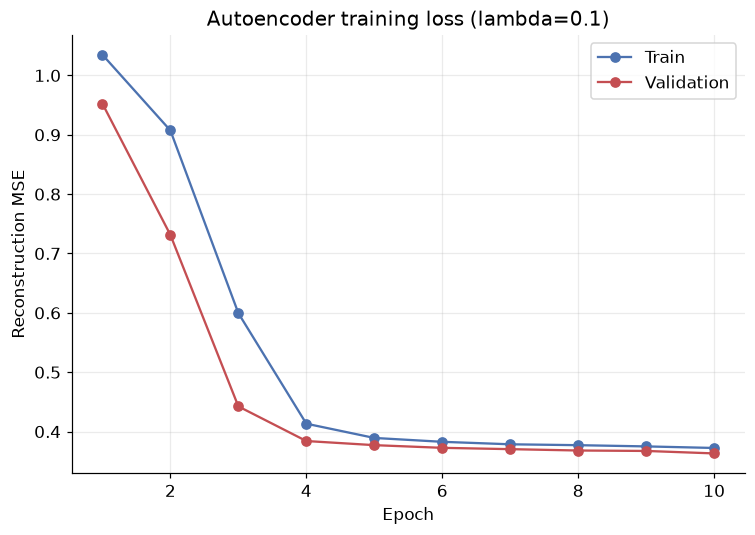

In [5]:
LAM_MAIN = 0.1
LAM_ALT = 0.05

N_TRAIN_IC = 300
TRAIN_MAX_STEPS = 50
MAX_TRAIN_WINDOWS = 3000
CNN_EPOCHS = 10
BATCH_SIZE = 64


def build_training_windows(lam, mu0, Sigma, n_train_ic, train_max_steps, window,
                            max_windows, rng):
    '''Simulate in-control paths, build+subsample windows, and fit a channel-wise scaler.'''
    Z, T2 = simulate_mewma_paths(mu0, Sigma, lam, np.zeros(len(mu0)), n_train_ic,
                                  train_max_steps, rng)
    windows = make_windows(Z, T2, window)
    if len(windows) > max_windows:
        idx = rng.choice(len(windows), size=max_windows, replace=False)
        windows = windows[idx]
    w_mean, w_std = fit_window_scaler(windows)
    windows_scaled = apply_window_scaler(windows, w_mean, w_std)
    return windows_scaled, w_mean, w_std


def train_autoencoder(windows_scaled, window, n_channels, epochs, batch_size, rng):
    '''Train a ConvAutoencoder by self-reconstruction on in-control windows only.'''
    X = torch.tensor(windows_scaled, dtype=torch.float32)
    n = len(X)
    perm = rng.permutation(n)
    n_val = int(0.15 * n)
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    train_loader = DataLoader(TensorDataset(X[train_idx], X[train_idx]),
                               batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X[val_idx], X[val_idx]),
                             batch_size=batch_size, shuffle=False)

    model = ConvAutoencoder(window=window, n_channels=n_channels).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    def run_epoch(loader, train):
        model.train(train)
        total_loss, n_obs = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.set_grad_enabled(train):
                recon = model(xb)
                loss = criterion(recon, yb)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * xb.size(0)
            n_obs += xb.size(0)
        return total_loss / n_obs

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        history["train_loss"].append(run_epoch(train_loader, True))
        history["val_loss"].append(run_epoch(val_loader, False))
    return model, history


windows_train_main, w_mean_main, w_std_main = build_training_windows(
    LAM_MAIN, MU0, SIGMA, N_TRAIN_IC, TRAIN_MAX_STEPS, WINDOW, MAX_TRAIN_WINDOWS, RNG)
model_main, history_main = train_autoencoder(
    windows_train_main, WINDOW, N_CHANNELS, CNN_EPOCHS, BATCH_SIZE, RNG)

fig, ax = plt.subplots()
ax.plot(range(1, CNN_EPOCHS + 1), history_main["train_loss"], marker="o", color=COL_V1, label="Train")
ax.plot(range(1, CNN_EPOCHS + 1), history_main["val_loss"], marker="o", color=COL_LIMITS, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction MSE")
ax.set_title(fr"Autoencoder training loss (lambda={LAM_MAIN})")
ax.legend()
plt.tight_layout()
plt.show()


## 7. From CNN to a 17-dimensional feature vector

Two quantities come out of the trained autoencoder for each window: the 16-dimensional bottleneck (`encode()`) and the reconstruction MSE (how well `forward()`'s output matches the input). Concatenating them gives a 17-d feature vector per window — the input space the One-Class SVM will work in.

In [6]:
def encode_features(model, windows_scaled, batch_size=256):
    model.eval()
    X = torch.tensor(windows_scaled, dtype=torch.float32)
    feats = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i + batch_size].to(DEVICE)
            feats.append(model.encode(xb).cpu().numpy())
    return np.concatenate(feats)


def reconstruction_error(model, windows_scaled, batch_size=256):
    model.eval()
    X = torch.tensor(windows_scaled, dtype=torch.float32)
    errs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = X[i:i + batch_size].to(DEVICE)
            recon = model(xb)
            errs.append(((recon - xb) ** 2).mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(errs)


def ocsvm_feature_vector(model, windows_scaled, batch_size=256):
    '''17-d feature vector: 16 bottleneck features + 1 reconstruction-error scalar.'''
    feats = encode_features(model, windows_scaled, batch_size)
    err = reconstruction_error(model, windows_scaled, batch_size)
    return np.concatenate([feats, err[:, None]], axis=1)


F_train_main = ocsvm_feature_vector(model_main, windows_train_main)
print("Training feature matrix shape:", F_train_main.shape, "-- (n_windows, 16 bottleneck + 1 error)")


Training feature matrix shape: (3000, 17) -- (n_windows, 16 bottleneck + 1 error)


## 8. One-Class SVM on top of the CNN features

Recapping only briefly (see `SVM_and_OneClassSVM_Tutorial.ipynb` for the full margin/$\nu$/$\gamma$ story): a One-Class SVM with an RBF kernel learns a boundary around the bulk of the training data, with $\nu$ controlling (approximately) the fraction of training points allowed to fall outside it. We fit it on the 17-d in-control features only, inside a pipeline with its own standardisation step.

`decision_function` follows sklearn's convention: **positive means inlier, negative means outlier**. We negate it so that, consistently with $T^2$, **higher always means more anomalous**.

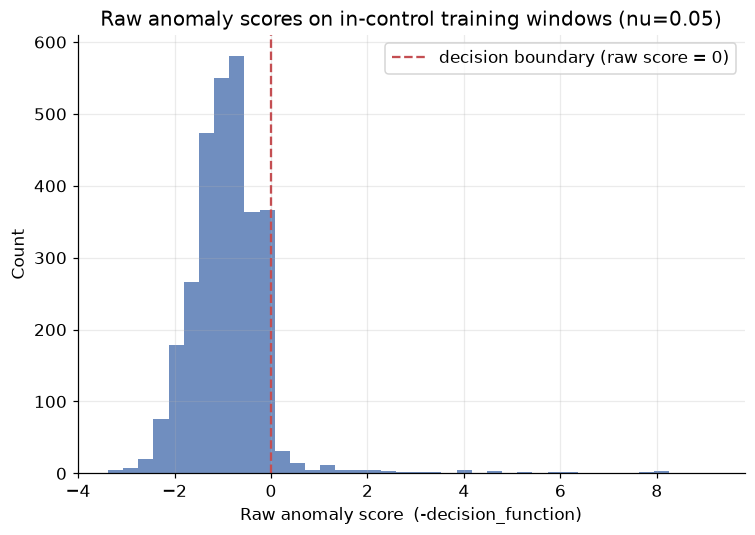

Fraction of IC training windows flagged as outliers by the raw OCSVM boundary: 0.051
(Expected to be in the neighbourhood of nu=0.05 by construction.)


In [7]:
OCSVM_NU = 0.05
OCSVM_GAMMA = "scale"
ALPHA = 0.65


def fit_ocsvm(F_train, nu=OCSVM_NU, gamma=OCSVM_GAMMA):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)),
    ])
    pipeline.fit(F_train)
    return pipeline


def anomaly_score(pipeline, F):
    '''Higher = more anomalous (sklearn's decision_function is the opposite convention).'''
    return -pipeline.decision_function(F)


ocsvm_main = fit_ocsvm(F_train_main)
anomaly_train_main = anomaly_score(ocsvm_main, F_train_main)

fig, ax = plt.subplots()
ax.hist(anomaly_train_main, bins=40, color=COL_V1, alpha=0.8)
ax.axvline(0.0, color=COL_LIMITS, linestyle="--", label="decision boundary (raw score = 0)")
ax.set_xlabel("Raw anomaly score  (-decision_function)")
ax.set_ylabel("Count")
ax.set_title(fr"Raw anomaly scores on in-control training windows (nu={OCSVM_NU})")
ax.legend()
plt.tight_layout()
plt.show()

frac_flagged = (anomaly_train_main > 0).mean()
print(f"Fraction of IC training windows flagged as outliers by the raw OCSVM boundary: {frac_flagged:.3f}")
print(f"(Expected to be in the neighbourhood of nu={OCSVM_NU} by construction.)")


## 9. Calibrating the anomaly score onto $[0,1]$

The raw anomaly score has no fixed scale — it depends on the SVM's decision-function geometry. We rescale it onto $[0,1]$ using a `MinMaxScaler` **fit only on a fresh batch of in-control calibration paths** (distinct from the training paths above), and clip to $[0,1]$ so it stays comparable across every later shift magnitude. This scaler, like the window scaler and the autoencoder, is then frozen.

In [8]:
N_CAL = 300
CAL_MAX_STEPS = 500


def calibration_batch(lam, mu0, Sigma, n_cal, cal_max_steps, window, model, w_mean, w_std,
                       ocsvm_pipeline, rng):
    '''Simulate fresh in-control calibration paths and score them through the frozen
    window scaler + autoencoder + OCSVM. Returns (T2_matrix, anomaly_raw_matrix), both
    shape (n_cal, cal_max_steps).'''
    Z_cal, T2_cal = simulate_mewma_paths(mu0, Sigma, lam, np.zeros(len(mu0)), n_cal,
                                          cal_max_steps, rng)
    windows_cal = make_windows(Z_cal, T2_cal, window)
    windows_cal_scaled = apply_window_scaler(windows_cal, w_mean, w_std)
    F_cal = ocsvm_feature_vector(model, windows_cal_scaled)
    anomaly_raw = anomaly_score(ocsvm_pipeline, F_cal)
    return T2_cal, anomaly_raw.reshape(n_cal, cal_max_steps)


T2_cal_main, anomaly_raw_cal_main = calibration_batch(
    LAM_MAIN, MU0, SIGMA, N_CAL, CAL_MAX_STEPS, WINDOW, model_main, w_mean_main, w_std_main,
    ocsvm_main, RNG)

anomaly_scaler_main = MinMaxScaler()
anomaly_scaler_main.fit(anomaly_raw_cal_main.reshape(-1, 1))


def scale_anomaly(anomaly_raw, scaler, shape):
    scaled = scaler.transform(anomaly_raw.reshape(-1, 1)).ravel()
    return np.clip(scaled, 0.0, 1.0).reshape(shape)


anomaly_cal_main = scale_anomaly(anomaly_raw_cal_main, anomaly_scaler_main, T2_cal_main.shape)
print("Calibration T2 matrix shape:     ", T2_cal_main.shape)
print("Calibration anomaly matrix shape:", anomaly_cal_main.shape)
print(f"Scaled anomaly score range: [{anomaly_cal_main.min():.3f}, {anomaly_cal_main.max():.3f}]")


Calibration T2 matrix shape:      (300, 500)
Calibration anomaly matrix shape: (300, 500)
Scaled anomaly score range: [0.000, 1.000]


## 10. The hybrid score

$$
S_t = \alpha \cdot \min\!\left(\frac{T_t^2}{H},\, 8\right) + (1-\alpha)\cdot a_t
$$

where $a_t\in[0,1]$ is the calibrated anomaly score from Section 9, and $H$ is a **separate, purely classical MEWMA quantity** — a control limit for $T^2$ alone, calibrated to the same target $ARL_0=200$ using exactly the bisection idea from `MEWMA_Control_Chart_Tutorial.ipynb`'s Section 9. Its role here is only to rescale $T_t^2$ onto a range comparable to $a_t$ before combining (capped at 8 so a runaway $T^2$ can't swamp the anomaly-score contribution). $H$ is **not** the limit the hybrid chart actually monitors against — the hybrid score $S_t$ gets its *own* independently-calibrated limit in Section 11.

We write the bisection logic **once**, as a generic helper operating on any precomputed in-control score matrix (works for $T^2$, for $S$, or for anything else) — used here to find $H$, and reused unchanged in Section 11 to find the hybrid limit.

In [9]:
def first_crossing_run_lengths(score_matrix, limit):
    '''Vectorized first-crossing run length per row. score_matrix: (n_paths, max_steps).
    Returns an (n_paths,) array, censored at max_steps if the path never crosses.'''
    n_paths, max_steps = score_matrix.shape
    exceeds = score_matrix > limit
    any_exceed = exceeds.any(axis=1)
    first_idx = np.argmax(exceeds, axis=1)   # first True index per row (meaningless if none)
    return np.where(any_exceed, first_idx + 1, max_steps)


def calibrate_limit_from_scores(score_matrix, target_arl0, n_iter=15):
    '''Bisection search for the limit whose mean first-crossing run length matches target_arl0.
    Returns (limit, search_log) where search_log is a list of (iteration, limit, ARL0) tuples.'''
    lo, hi = 0.0, float(score_matrix.max())
    search_log = []
    for it in range(n_iter):
        mid = 0.5 * (lo + hi)
        arl0 = first_crossing_run_lengths(score_matrix, mid).mean()
        search_log.append((it, mid, arl0))
        if arl0 < target_arl0:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi), search_log


def hybrid_score(t2_matrix, anomaly_scaled_matrix, H, alpha=ALPHA):
    t2_scaled = np.minimum(t2_matrix / max(H, 1e-12), 8.0)
    return alpha * t2_scaled + (1 - alpha) * anomaly_scaled_matrix


H_main, H_log_main = calibrate_limit_from_scores(T2_cal_main, ARL0_TARGET)
H_table_main = pd.DataFrame(H_log_main, columns=["iteration", "H", "ARL0 estimate"])
display(H_table_main)
print(f"\nCalibrated H (lambda={LAM_MAIN}): {H_main:.3f}")


,iteration,H,ARL0 estimate
0,0,9.681537,248.290000
1,1,4.840769,38.783333
2,2,7.261153,105.803333
3,3,8.471345,160.040000
4,4,9.076441,200.843333
5,5,8.773893,181.356667
6,6,8.925167,191.186667
7,7,9.000804,194.986667
8,8,9.038623,196.896667
9,9,9.057532,198.740000



Calibrated H (lambda=0.1): 9.068


## 11. Calibrating the hybrid control limit

Using the same in-control calibration paths (no need to resimulate), we compute the full hybrid score matrix $S$ once and bisect its control limit $L_{\text{hybrid}}$ to the same $ARL_0=200$ target, exactly as we just did for $H$.

In [10]:
S_cal_main = hybrid_score(T2_cal_main, anomaly_cal_main, H_main, ALPHA)
L_hybrid_main, L_log_main = calibrate_limit_from_scores(S_cal_main, ARL0_TARGET)
L_table_main = pd.DataFrame(L_log_main, columns=["iteration", "L_hybrid", "ARL0 estimate"])
display(L_table_main)
print(f"\nCalibrated hybrid limit L_hybrid (lambda={LAM_MAIN}): {L_hybrid_main:.3f}")

# Package everything this lambda's pipeline needs for later scoring into one dict.
results = {}
results[LAM_MAIN] = {
    "lam": LAM_MAIN, "model": model_main, "history": history_main,
    "w_mean": w_mean_main, "w_std": w_std_main, "ocsvm_pipeline": ocsvm_main,
    "anomaly_scaler": anomaly_scaler_main, "H": H_main, "L_hybrid": L_hybrid_main,
}
print("\nStored pipeline results for lambda =", LAM_MAIN)


,iteration,L_hybrid,ARL0 estimate
0,0,0.863847,316.620000
1,1,0.431924,47.740000
2,2,0.647885,145.146667
3,3,0.755866,229.896667
4,4,0.701876,183.560000
5,5,0.728871,210.236667
6,6,0.715373,197.650000
7,7,0.722122,204.793333
8,8,0.718748,202.316667
9,9,0.717061,201.340000



Calibrated hybrid limit L_hybrid (lambda=0.1): 0.717

Stored pipeline results for lambda = 0.1


## 12. Wrapping it into a reusable pipeline, and repeating at $\lambda=0.05$

Sections 6-11 walked through the whole pipeline step by step for $\lambda=0.1$. Since $\lambda$ changes the very statistic ($Z_i$, and hence $T_i^2$ and every window built from them) the CNN and OCSVM are trained on, checking whether our conclusions depend on $\lambda$ means training and calibrating an **entirely separate** pipeline at $\lambda=0.05$ — not just re-plotting the same numbers.

`run_hybrid_pipeline` below simply chains together the exact same helper functions used above, so there is no duplicated logic — only the orchestration is new. $\lambda=0.1$'s results from Sections 6-11 are reused as-is; only $\lambda=0.05$ is actually computed here.

In [11]:
def run_hybrid_pipeline(lam, mu0, Sigma, rng,
                         n_train_ic=N_TRAIN_IC, train_max_steps=TRAIN_MAX_STEPS,
                         max_windows=MAX_TRAIN_WINDOWS, window=WINDOW,
                         epochs=CNN_EPOCHS, batch_size=BATCH_SIZE,
                         n_cal=N_CAL, cal_max_steps=CAL_MAX_STEPS,
                         alpha=ALPHA, target_arl0=ARL0_TARGET):
    '''Run the full train+calibrate pipeline for one lambda value. Returns a dict with
    everything needed to score fresh paths later on: the frozen model, OCSVM, scalers,
    and both calibrated control limits.'''
    windows_train, w_mean, w_std = build_training_windows(
        lam, mu0, Sigma, n_train_ic, train_max_steps, window, max_windows, rng)
    model, history = train_autoencoder(windows_train, window, len(mu0) + 1, epochs, batch_size, rng)

    F_train = ocsvm_feature_vector(model, windows_train)
    ocsvm_pipeline = fit_ocsvm(F_train)

    T2_cal, anomaly_raw_cal = calibration_batch(
        lam, mu0, Sigma, n_cal, cal_max_steps, window, model, w_mean, w_std, ocsvm_pipeline, rng)
    anomaly_scaler = MinMaxScaler()
    anomaly_scaler.fit(anomaly_raw_cal.reshape(-1, 1))
    anomaly_cal = scale_anomaly(anomaly_raw_cal, anomaly_scaler, T2_cal.shape)

    H, _ = calibrate_limit_from_scores(T2_cal, target_arl0)
    S_cal = hybrid_score(T2_cal, anomaly_cal, H, alpha)
    L_hybrid, _ = calibrate_limit_from_scores(S_cal, target_arl0)

    return {
        "lam": lam, "model": model, "history": history, "w_mean": w_mean, "w_std": w_std,
        "ocsvm_pipeline": ocsvm_pipeline, "anomaly_scaler": anomaly_scaler,
        "H": H, "L_hybrid": L_hybrid,
    }


results[LAM_ALT] = run_hybrid_pipeline(LAM_ALT, MU0, SIGMA, RNG)

print("Calibrated constants by lambda:")
for lam in (LAM_MAIN, LAM_ALT):
    r = results[lam]
    print(f"  lambda={lam}: H={r['H']:.3f}, L_hybrid={r['L_hybrid']:.3f}")


Calibrated constants by lambda:
  lambda=0.1: H=9.068, L_hybrid=0.717
  lambda=0.05: H=7.581, L_hybrid=0.710


## 13. ARL comparison: classical MEWMA vs. the hybrid score, at both $\lambda$ values

For each $\lambda$ and each shift magnitude $\delta$ (a sustained mean shift in the first coordinate only, $\text{shift}=(\delta, 0)$, matching the sibling research project), we simulate **one** shared batch of paths and evaluate *both* monitors on the *exact same* simulated data:

* the classical monitor: $T_t^2$ against its own limit $H$ (conveniently, $H$ from Section 10 already *is* the correctly-calibrated standalone classical MEWMA limit — it doesn't need a third, separate calibration);
* the hybrid monitor: $S_t$ against $L_{\text{hybrid}}$.

Using the same simulated paths for both is a deliberate **paired comparison** (common random numbers): any ARL difference we see reflects a genuine difference in detection power, not independent Monte Carlo noise between two separately-simulated experiments.

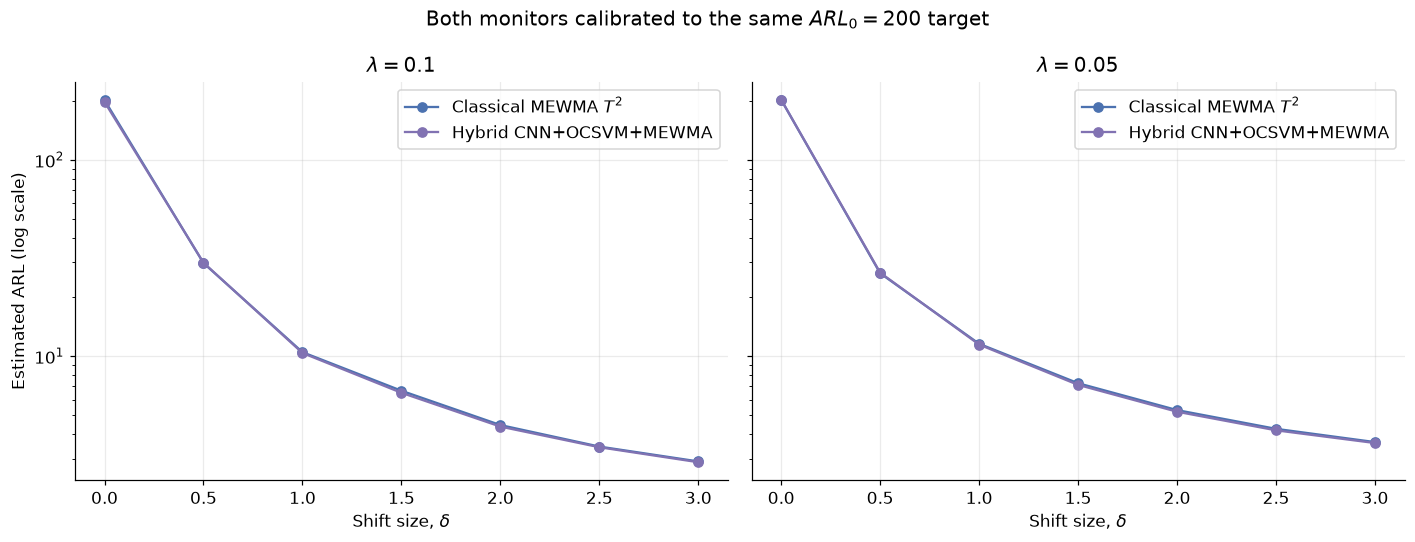

,lam,delta,ARL_classical,SE_classical,ARL_hybrid,SE_hybrid
0,0.10,0.0,201.08,13.13,196.75,13.31
1,0.10,0.5,29.75,1.58,29.87,1.61
2,0.10,1.0,10.47,0.40,10.37,0.40
3,0.10,1.5,6.66,0.21,6.50,0.21
4,0.10,2.0,4.45,0.12,4.37,0.12
5,0.10,2.5,3.46,0.07,3.43,0.07
6,0.10,3.0,2.91,0.05,2.88,0.05
7,0.05,0.0,201.77,13.03,201.97,13.16
8,0.05,0.5,26.39,1.21,26.58,1.20
9,0.05,1.0,11.55,0.33,11.44,0.34


In [12]:
DELTA_GRID = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
N_ARL = 150
ARL_MAX_STEPS = 500


def run_arl_sweep(pipeline_results, mu0, Sigma, delta_grid, n_arl, arl_max_steps, rng, alpha=ALPHA):
    rows = []
    for delta in delta_grid:
        shift = np.array([delta, 0.0])
        Z_arl, T2_arl = simulate_mewma_paths(mu0, Sigma, pipeline_results["lam"], shift,
                                              n_arl, arl_max_steps, rng)
        windows_arl = make_windows(Z_arl, T2_arl, WINDOW)
        windows_arl_scaled = apply_window_scaler(windows_arl, pipeline_results["w_mean"],
                                                  pipeline_results["w_std"])
        F_arl = ocsvm_feature_vector(pipeline_results["model"], windows_arl_scaled)
        anomaly_raw_arl = anomaly_score(pipeline_results["ocsvm_pipeline"], F_arl)
        anomaly_arl = scale_anomaly(anomaly_raw_arl, pipeline_results["anomaly_scaler"], T2_arl.shape)
        S_arl = hybrid_score(T2_arl, anomaly_arl, pipeline_results["H"], alpha)

        rl_classical = first_crossing_run_lengths(T2_arl, pipeline_results["H"])
        rl_hybrid = first_crossing_run_lengths(S_arl, pipeline_results["L_hybrid"])

        rows.append({
            "delta": delta,
            "ARL_classical": rl_classical.mean(),
            "SE_classical": rl_classical.std(ddof=1) / np.sqrt(n_arl),
            "ARL_hybrid": rl_hybrid.mean(),
            "SE_hybrid": rl_hybrid.std(ddof=1) / np.sqrt(n_arl),
        })
    return pd.DataFrame(rows)


sweep_results = {}
for lam in (LAM_MAIN, LAM_ALT):
    sweep_results[lam] = run_arl_sweep(results[lam], MU0, SIGMA, DELTA_GRID, N_ARL,
                                        ARL_MAX_STEPS, RNG)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, lam in zip(axes, (LAM_MAIN, LAM_ALT)):
    df = sweep_results[lam]
    ax.plot(df["delta"], df["ARL_classical"], marker="o", color=COL_CLASSICAL, label="Classical MEWMA $T^2$")
    ax.plot(df["delta"], df["ARL_hybrid"], marker="o", color=COL_HYBRID, label="Hybrid CNN+OCSVM+MEWMA")
    ax.set_yscale("log")
    ax.set_xlabel(r"Shift size, $\delta$")
    ax.set_title(fr"$\lambda={lam}$")
    ax.legend()
axes[0].set_ylabel("Estimated ARL (log scale)")
fig.suptitle(r"Both monitors calibrated to the same $ARL_0=200$ target")
plt.tight_layout()
plt.show()

combined_table = pd.concat(
    [sweep_results[lam].assign(lam=lam) for lam in (LAM_MAIN, LAM_ALT)],
    ignore_index=True,
)[["lam", "delta", "ARL_classical", "SE_classical", "ARL_hybrid", "SE_hybrid"]]
display(combined_table.round(2))


**Reading the table above**: compare `ARL_classical` and `ARL_hybrid` at each $\delta$ against their standard errors (`SE_classical`/`SE_hybrid`) before concluding one monitor is genuinely faster — a gap smaller than a couple of standard errors is Monte Carlo noise, not a real effect. As anticipated in Section 3, since our simulated anomaly is exactly a sustained mean shift, the honest expectation was that the hybrid chart would *at least keep up* with classical MEWMA rather than dramatically outperform it — check whether that's what the numbers above actually show, at both $\lambda$ values. If the two monitors track each other closely, that is not a failure of the hybrid pipeline: it is exactly what Section 3 predicted, and the real payoff of a CNN's temporal-shape sensitivity should show up more clearly for anomalies that don't look like a clean, sustained shift in the mean.

## 14. Summary and key takeaways

| Concept | Formula / definition |
|---|---|
| Rolling window | last `WINDOW=12` values of $(Z_1, Z_2, T^2)$, zero-padded at path start |
| Autoencoder loss | $\text{MSE}(\hat{\mathbf{w}}, \mathbf{w})$ over the reconstructed window, in-control windows only |
| OCSVM feature vector | 16-d bottleneck $\Vert$ 1-d reconstruction error (17-d total) |
| Anomaly score | $a_t = \text{clip}(\text{MinMax}(-\text{decision\_function}(F_t)),\ 0,\ 1)$ |
| Hybrid score | $S_t = \alpha\cdot\min(T_t^2/H,\ 8) + (1-\alpha)\cdot a_t$ |
| Calibration | bisection on a precomputed in-control score matrix, targeting $ARL_0=200$ |

**What we learned:**

* An autoencoder trained only on in-control data turns reconstruction error into a label-free anomaly signal, in exactly the same spirit as a One-Class SVM — and the two combine naturally, with the CNN acting as an unsupervised feature-learner feeding an unsupervised detector.
* Every fitted piece of this pipeline (window scaler, autoencoder, OCSVM, anomaly rescaler, both control limits) must be fit on in-control data only and then **frozen** before touching any shifted scenario — refitting anything per shift would make the ARL study meaningless.
* $\lambda$ changes the underlying statistic the CNN is trained on, not just a downstream control limit — which is why comparing $\lambda$ values here meant retraining the *entire* pipeline, not just re-plotting a curve.
* The honest empirical verdict (see Section 13's discussion) is a specific instance of a general point: an anomaly detector's advantage depends on whether its inductive bias matches the anomaly's actual shape, not simply on how much extra machinery is bolted on.

**Looking ahead**: this notebook simulated exactly one anomaly type — a sustained mean shift — because that matches the classical $T^2$ statistic's own design target and lets the comparison be apples-to-apples. A natural next step is a **non-mean-shift anomaly** (a transient spike, an oscillation, or a variance/autocorrelation change) that $T^2$ is *not* specifically tuned for, where the CNN's sensitivity to temporal shape would be expected to matter more.